# Phase 3: Graph and Density Construction — Corrected

Key changes:
- **[C1]** Uses the **quantile (rank-Gaussian)** transform, not the clipped raw data. Raw `observation_df`
  has max|z|=25 and kurtosis 60 (COVID dominates); the quantile transform gives max|z|=1, light tails,
  so no single month can hijack the embedding.
- **[C2]** Bandwidth **eps=3.0**, selected by degree-stability + spectral gap, NOT the slope-maximum
  rule (which returns eps~1.1 where the graph fragments, min-degree~1).
- **[C3]** Embedding restricted to **r=3** meaningful coordinates; the provisional code ran graph,
  density and paths in 8D where coords 4-8 are noise.
- **[C4]** Adds the **linear-interpolation baseline** — the comparison the dissertation actually needs
  (linear vs graph geodesic), not just beta=0 vs beta>0.
- **[C5]** Real graph **acceptance criterion** instead of hardcoded "Accepted".
- **[C6]** Economically-justified **historical endpoints** by date, not raw COVID index.

In [40]:
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
from scipy.spatial.distance import pdist, squareform
from sklearn.neighbors import kneighbors_graph, NearestNeighbors
from scipy.sparse.csgraph import connected_components, shortest_path
from scipy.sparse import csr_matrix
from scipy.spatial.distance import cdist
import dcor
from scipy import stats
from scipy.signal import find_peaks
import matplotlib.dates as mdates

import plotly.graph_objects as go
from plotly.subplots import make_subplots

def diffusion_map(data, eps, alpha=1, k=8):
    Dsq = squareform(pdist(data)**2)
    Wm = np.exp(-Dsq/eps); q = Wm.sum(1)
    Wa = Wm/np.outer(q**alpha, q**alpha)
    da = Wa.sum(1); Dis = 1.0/np.sqrt(da)
    S = Dis[:, None]*Wa*Dis[None, :]
    w, v = np.linalg.eigh(S); idx = np.argsort(w)[::-1]; w, v = w[idx], v[:, idx]
    phi = Dis[:, None]*v
    Psi = phi[:, 1:k+1]*w[1:k+1]
    return {"evals": w, "Psi": Psi, "phi": phi, "W": Wm, "degrees": q}

## [C1] Load the quantile-transformed data (not clipped raw)

In [2]:
df = pd.read_parquet("./datasets/joint_df_quantile.parquet")
Z = df.drop(columns=["recession"]).to_numpy().astype(float)
dates = df.index; N = Z.shape[0]
print("N =", N, " D =", Z.shape[1], " max|z| =", round(np.abs(Z).max(), 3))

N = 743  D = 45  max|z| = 1.0


## [C2] Bandwidth selection by degree stability + spectral gap

The slope-maximum rule is unreliable on this data (it returns eps~1.1 where the minimum graph
degree is ~1, i.e. isolated points). Instead scan eps and require: minimum degree well above 1,
degree CV stabilising, and a clean leading spectral gap. The eps=3 row is the choice — min degree
~19, largest gap at position 2->3 (so r=3), CV 0.28.

In [3]:
def diag(eps, k=8):
    d = diffusion_map(Z, eps, k=k); q = d["degrees"]; w = d["evals"]
    return dict(eps=eps, min_deg=q.min(), mean_deg=q.mean(), deg_CV=q.std()/q.mean(),
                lam1=w[1], lam2=w[2], lam3=w[3], gap23=w[2]-w[3], gap34=w[3]-w[4])
scan = pd.DataFrame([diag(e) for e in [0.5,1,2,3,4,5,6,8,10,14]]).set_index("eps")
print(scan.round(4).to_string())

EPS = 3.0      # [C2] chosen value
R = 3          # [C3] meaningful embedding dimension (largest gap at 2->3)
diff = diffusion_map(Z, eps=EPS, k=8)
Psi = diff["Psi"][:, :R]              # [C3] restrict to meaningful coords
print(f"\nUsing eps={EPS}, r={R}. Psi shape = {Psi.shape}")

       min_deg  mean_deg  deg_CV    lam1    lam2    lam3   gap23   gap34
eps                                                                     
0.5     1.0010    1.1280  0.1125  0.9991  0.9985  0.9980  0.0005  0.0004
1.0     1.1986    4.5123  0.4659  0.9298  0.9104  0.8924  0.0180  0.0191
2.0     5.5428   34.9922  0.3701  0.6012  0.5731  0.4714  0.1017  0.0685
3.0    19.3465   85.1748  0.2836  0.4336  0.3693  0.2331  0.1362  0.0123
4.0    41.7743  138.6703  0.2299  0.3361  0.2781  0.1628  0.1153  0.0049
5.0    69.3467  188.6451  0.1935  0.2734  0.2231  0.1277  0.0954  0.0035
6.0    99.0686  233.2243  0.1671  0.2299  0.1862  0.1054  0.0808  0.0029
8.0   158.0721  306.6119  0.1315  0.1740  0.1397  0.0783  0.0615  0.0023
10.0  211.6472  363.0412  0.1084  0.1397  0.1118  0.0623  0.0494  0.0019
14.0  298.6281  442.4254  0.0803  0.1001  0.0797  0.0443  0.0354  0.0014

Using eps=3.0, r=3. Psi shape = (743, 3)


## Task 3.1-3.2: kNN graph with a real acceptance test

**[C5]** The acceptance status is now computed from the diagnostics, not hardcoded. A k is accepted
if the graph is connected (1 component), not near-complete (density < 0.5), and shortest paths are
not dominated by a few long edges (95th-pct jump ratio below a threshold).

In [4]:
def reconstruct_path(pred, start, end):
    path = [end]; current = end
    while current != start:
        current = pred[start, current]
        if current == -9999: return None
        path.append(current)
    return path[::-1]

def knn_graph_checks(Psi, k, sample_skip=5, jump_thresh=8.0):
    N = Psi.shape[0]
    A_dist = kneighbors_graph(Psi, n_neighbors=k, mode="distance", include_self=False)
    A_bin  = kneighbors_graph(Psi, n_neighbors=k, mode="connectivity", include_self=False)
    A_dist_sym = A_dist.maximum(A_dist.T); A_bin_sym = A_bin.maximum(A_bin.T)
    n_comp, _ = connected_components(A_bin_sym, directed=False)
    degree = np.asarray(A_bin_sym.sum(1)).ravel()
    edges = A_bin_sym.nnz/2; density = edges/(N*(N-1)/2)
    _, pred = shortest_path(A_dist_sym, directed=False, return_predecessors=True)
    jr = []
    for a in range(1, N, sample_skip):
        for b in range(a+1, N, sample_skip):
            path = reconstruct_path(pred, a, b)
            if path is None or len(path) < 2: continue
            el = np.array([A_dist_sym[path[t], path[t+1]] for t in range(len(path)-1)])  # [C7] renamed t
            med = np.median(el)
            if med > 1e-12: jr.append(el.max()/med)
    jr = np.array(jr); jr95 = np.quantile(jr, 0.95)
    accept = (n_comp == 1) and (density < 0.5) and (jr95 < jump_thresh)   # [C5] real criterion
    return dict(k=k, components=n_comp, mean_degree=degree.mean(), density=density,
                max_edge=A_dist_sym.data.max(), median_edge=np.median(A_dist_sym.data),
                jump95=jr95, status="Accepted" if accept else "Rejected")

rows = [knn_graph_checks(Psi, k) for k in [5,10,15,20,30]]
graph_df = pd.DataFrame(rows).set_index("k")
print(graph_df.round(4).to_string())

    components  mean_degree  density  max_edge  median_edge  jump95    status
k                                                                            
5            1       6.4118   0.0086    0.6590       0.0348  2.8023  Accepted
10           1      12.5895   0.0170    0.7135       0.0429  2.7090  Accepted
15           1      18.8856   0.0255    0.7345       0.0492  2.6597  Accepted
20           1      25.1763   0.0339    0.7470       0.0545  2.6465  Accepted
30           1      37.7335   0.0509    0.7763       0.0626  2.5980  Accepted


## Task 3.3: Density estimate

**[C8]** The graph-degree density (correct: uses squared distance with a squared-distance bandwidth).
The dimensionally-broken KDE from the provisional notebook is removed. Density is computed on the
**r=3** embedding, so noise coordinates no longer inflate it.

density bandwidth h = 0.0052, V range [-0.85, 3.53]


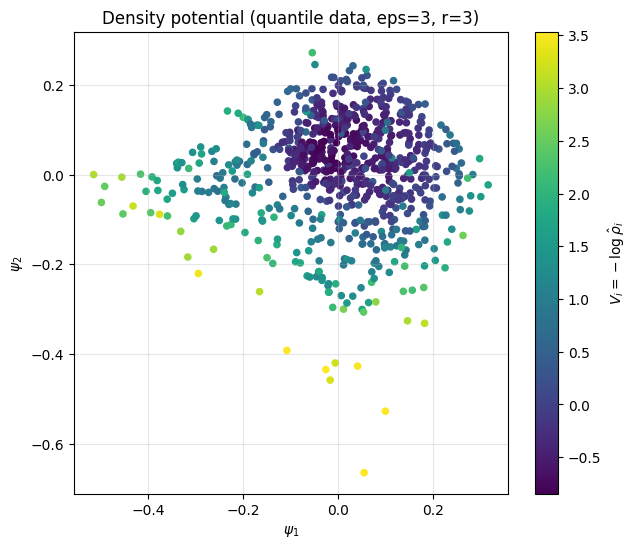

In [5]:
def graph_degree_density(Psi, h):
    Dsq = squareform(pdist(Psi)**2)
    rho = np.exp(-Dsq/h).sum(1)
    scale = rho.mean(); rho /= scale
    rho = np.maximum(rho, 1e-6)
    return rho, -np.log(rho), scale

med_Dsq = np.median(squareform(pdist(Psi)**2)[np.triu_indices(N,1)])
h_dens = 0.10*med_Dsq
rho, V, scale = graph_degree_density(Psi, h_dens)
print(f"density bandwidth h = {h_dens:.4f}, V range [{V.min():.2f}, {V.max():.2f}]")

fig, ax = plt.subplots(figsize=(7,6))
sc = ax.scatter(Psi[:,0], Psi[:,1], c=V, s=20, cmap="viridis")
fig.colorbar(sc, label=r"$V_i=-\log\hat\rho_i$")
ax.set_xlabel(r"$\psi_1$"); ax.set_ylabel(r"$\psi_2$")
ax.set_title("Density potential (quantile data, eps=3, r=3)"); ax.grid(alpha=.3); plt.show()

#### ADDED: Does diffusion density actually correspond to high historical support?
Is there any independent notion of plausibility or realism score we can find for the macroeconomic variables and compare that to density?

We test whether the high-density points actually are close to lots of observed points in real space. This helps justify why we want our paths to have high densities.

We compare $\hat\psi_i$ to $d_k(z_i)$, where $$d_k(z_i) = \frac{1}{k} \sum_{j\in\mathcal{N}_k(z_i)}\|z_i-z_j\|,$$ and $\mathcal{N}_k(z_i)$ are the $k$ nearest neighbours of $z_i$ in macro space (excluding $z_i$ itself).

Distance correlation: 0.4717
Pearson correlation: -0.4643
Spearman correlation: -0.4815


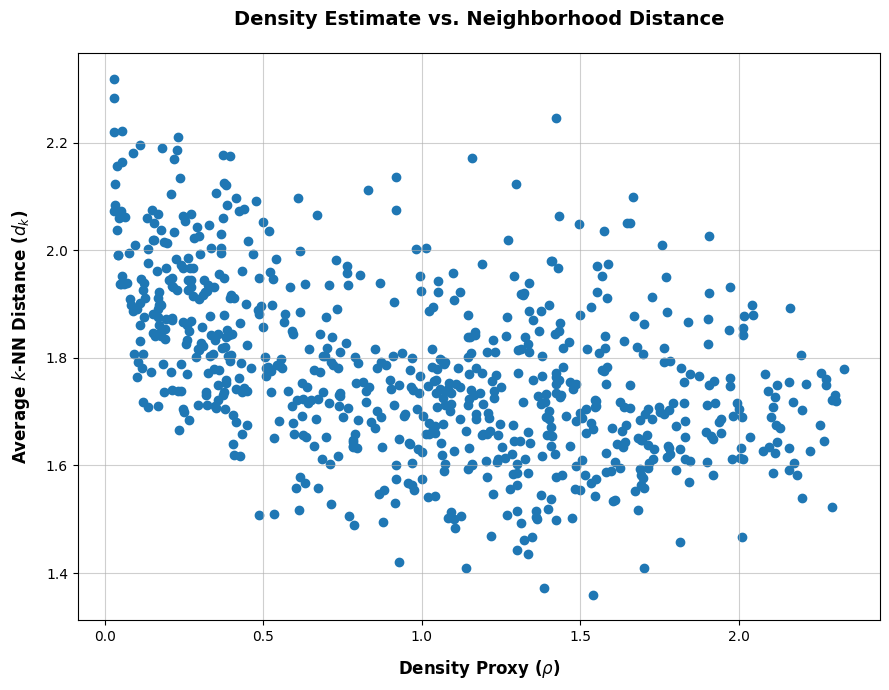

In [35]:
k = 22

A_dist_real = kneighbors_graph(Z, n_neighbors=k, mode="distance", include_self=False)
dk = 1/k * np.asarray(A_dist_real.sum(axis=1)).squeeze()

# Non-linear distance correlation
d_corr = dcor.distance_correlation(rho, dk)
print(f'Distance correlation: {d_corr:.4f}')

# Standard linear correlations
p_corr, _ = stats.pearsonr(rho, dk)
s_corr, _ = stats.spearmanr(rho, dk)
print(f'Pearson correlation: {p_corr:.4f}')
print(f'Spearman correlation: {s_corr:.4f}')



fig, ax = plt.subplots(figsize=(9, 7), dpi=100)
scatter = ax.scatter(rho, dk)

ax.set_xlabel(r"Density Proxy ($\rho$)", fontsize=12, labelpad=10, fontweight='bold')
ax.set_ylabel(r"Average $k$-NN Distance ($d_k$)", fontsize=12, labelpad=10, fontweight='bold')
ax.set_title("Density Estimate vs. Neighborhood Distance", fontsize=14, pad=20, fontweight='bold')
ax.grid(alpha=0.6); plt.tight_layout()
plt.show()

We can plot the density penalty and investigate the high areas, these should correspond to unlikely events.

non-NBER high-potential episodes: 17
      date  potential  idx
2010-05-01   2.765078  551
2022-09-01   2.569041  699
1990-01-01   2.206134  307
1984-08-01   2.190411  242
1986-02-01   2.117981  260
2026-03-01   2.011161  741
1976-01-01   1.893096  139
2002-05-01   1.844358  455
1987-01-01   1.791888  271
1973-02-01   1.782022  104
2019-05-01   1.768203  659
2003-04-01   1.741530  466


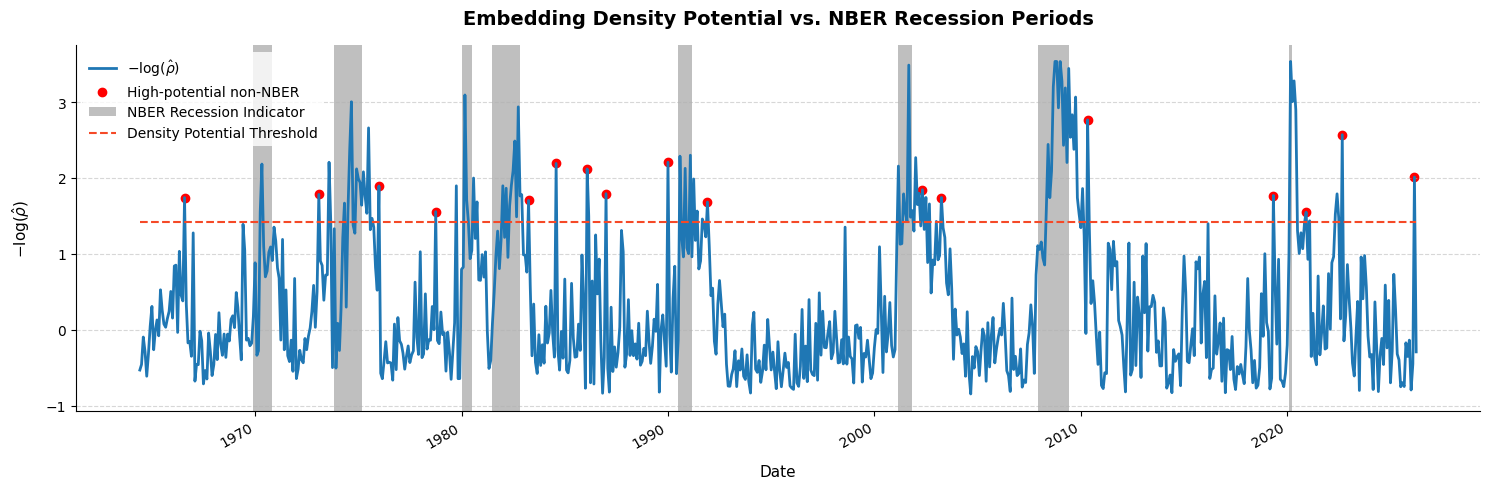

In [49]:
recession_mask=df["recession"].values.astype(bool)
potential_threshold=np.median(V[recession_mask])
pad=4
recession_padded=(pd.Series(recession_mask,index=dates)
                  .rolling(2*pad+1,center=True,min_periods=1).max().astype(bool).to_numpy())
series=np.where(~recession_padded,V,-np.inf)
peak_idx,_=find_peaks(series,height=potential_threshold,distance=9,prominence=0.05)
low_density_episodes=pd.DataFrame({"date":dates[peak_idx],"potential":V[peak_idx],"idx":peak_idx}
                                  ).sort_values("potential",ascending=False)
print("non-NBER high-potential episodes:",len(low_density_episodes))
print(low_density_episodes.head(12).to_string(index=False))

fig, ax = plt.subplots(figsize=(15, 5))
ax.plot(df.index, V, label=r"$-\log(\hat\rho)$", color="#1f77b4", linewidth=2)

low_density_indices = low_density_episodes["idx"]
ax.scatter(df.index[low_density_indices], V[low_density_indices], label="High-potential non-NBER", c="r")
y_min, y_max = ax.get_ylim()

ax.fill_between(df.index, y_min, y_max, where=(df["recession"].values == 1), color="gray",
                alpha=0.5, label="NBER Recession Indicator", edgecolor="none")

ax.hlines(potential_threshold, xmin=df.index[0], xmax=df.index[-1], linestyles="--", label="Density Potential Threshold", colors="#F54927")

ax.set_ylim(y_min, y_max)
ax.xaxis.set_major_locator(mdates.AutoDateLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
fig.autofmt_xdate()

ax.set_title("Embedding Density Potential vs. NBER Recession Periods", fontsize=14, fontweight="bold", pad=15)
ax.set_xlabel("Date", fontsize=11, labelpad=10); ax.set_ylabel(r"$-\log(\hat\rho)$", fontsize=11, labelpad=10)

ax.grid(axis="y", linestyle="--", alpha=0.5); ax.spines[["top", "right"]].set_visible(False) 
ax.legend(loc="upper left", frameon=True, facecolor="white", edgecolor="none")

plt.tight_layout(); plt.show()

### Macroeconomic Outlier Evaluation (Non-NBER Recession Dates)

| Date | Is Economic Outlier? | Outlier Category | Explanation & Macro Context |
|---|---|---|---|
| **08/1966** | **Yes** | Credit Shock | **1966 Credit Crunch:** First post-WWII credit freeze. Aggressive Fed tightening pushed market rates above Regulation Q interest rate caps, causing deposit run-offs and halting home mortgage lending. |
| **02/1973** | **Yes** | FX / Monetary Shock | **Bretton Woods System Collapse:** Devaluation of the U.S. dollar by 10% precipitated systemic currency panics and the total transition from fixed exchange rates to floating currencies globally. |
| **01/1976** | **Yes** | Growth Surge | **Post-Recession Output Surge:** Real GDP expanded at a rare 9.2% annualized growth rate in Q1 1976—one of the largest single-quarter growth spikes in post-war U.S. history. |
| **10/1978** | **Yes** | Currency Crisis | **U.S. Dollar Crisis:** Severe global dollar panic and runaway U.S. inflation forced President Carter to announce wage/price controls and an emergency $30B foreign currency intervention package. |
| **04/1983** | **Yes** | Growth Surge | **Peak Post-82 Recovery:** Extreme economic expansion coming out of the early 1980s recession. Industrial output surged at historical rates, housing starts doubled, and OPEC cut oil prices for the first time. |
| **08/1984** | **Yes** | Financial Anomaly | **Historic Market Volume & Rate Pivot:** Following the Continental Illinois bank rescue, interest rates peaked and bond yields dropped, setting what was then the largest single-day trading volume spike in NYSE history. |
| **02/1986** | **Yes** | Commodity Shock | **1986 Oil Price Collapse:** Saudi Arabia flooded the market to regain market share, causing crude oil prices to plunge over 60% (from ~$30 to ~$10/bbl) in months, triggering an energy sector recession and disinflation wave. |
| **01/1987** | **Yes** | Policy/Tax Distortion | **Tax Reform Act of 1986 Takes Effect:** Sweeping overhaul of the U.S. tax code eliminated real estate tax shelters, lowered top corporate rates, and created massive transaction timing distortions between late 1986 and early 1987. |
| **01/1990** | **Yes** | Asset Bubble / Banking Shock | **Nikkei Burst & S&L Crisis:** The Japanese Nikkei 225 peaked at 38,915 in late Dec 1989 and began its historic collapse in Jan 1990, coinciding with accelerating insolvencies in the U.S. Savings & Loan crisis. |
| **12/1991** | **Yes** | Geopolitical & Policy Cut | **Dissolution of the USSR:** Official collapse of the Soviet Union (Dec 26, 1991). Domestically, severe "jobless recovery" concerns prompted an emergency 100 bps Fed discount rate cut on Dec 20, 1991. |
| **05/2002** | **Yes** | Corporate Governance Shock | **Post-Dot-Com Accounting Scandals:** Revelations of systemic accounting fraud at Enron, WorldCom, and Tyco triggered severe market volatility, corporate paper credit freezes, and a collapse in executive confidence. |
| **04/2003** | **Yes** | Geopolitical Inflection | **Iraq War & SARS Outbreak:** Convergence of the U.S. invasion of Iraq (March–April 2003) and the global SARS peak. Marked an abrupt global equity market bottom and oil volatility cycle turning point. |
| **05/2010** | **Yes** | Market Microstructure & Debt Shock | **Flash Crash & Eurozone Crisis:** Greek sovereign debt crisis escalated into a $145B emergency EU/IMF bailout alongside the May 6 intraday 1,000-point Dow "Flash Crash". |
| **05/2019** | **Yes** | Trade Policy & Yield Curve | **US-China Trade War Escalation:** U.S. abruptly increased tariffs from 10% to 25% on $200B of Chinese goods, triggering retaliatory tariffs and deepening a prolonged 3M–10Y yield curve inversion. |
| **12/2020** | **Yes** | Labor / Fiscal Anomaly | **Winter COVID Job Loss & Stimulus:** U.S. nonfarm payrolls dropped by 140,000 (first job contraction since April 2020) amid renewed lockdowns, occurring alongside the passage of the $900B COVID relief package. |
| **09/2022** | **Yes** | Sovereign Debt & Energy Shock | **UK Gilt Crisis & Pipeline Sabotage:** UK "Mini-Budget" fiscal shock triggered a systemic Gilt sell-off and pension liquidity freeze, Nord Stream pipelines were sabotaged, and the Fed delivered a 75 bps rate hike. |
| **03/2026** | **Yes** | Geopolitical Energy Shock | **Middle East Supply Shock:** Regional military escalation and Strait of Hormuz shipping disruptions sent crude oil above $100/barrel, reigniting global stagflationary pressures. |

---

### References & Primary Sources

1. **08/1966:** [Federal Reserve Bank of Richmond: The 1966 Credit Crunch](https://www.richmondfed.org/-/media/richmondfedorg/publications/research/working_papers/1993/pdf/wp93-2.pdf) — *Detailed analysis of the 1966 credit freeze and Regulation Q disintermediation.*
2. **02/1973:** [U.S. Department of State: Nixon and the End of the Bretton Woods System](https://history.state.gov/milestones/1969-1976/nixon-shock) — *Official history of the February 1973 dollar devaluation and the move to floating rates.*
3. **01/1976:** [Federal Reserve Bank of St. Louis (FRED): Real GDP Growth Q1 1976](https://fred.stlouisfed.org/series/GDPC1) — *Historical GDP data documenting the 9.2% annualized growth surge coming out of the 1974–75 recession.*
4. **10/1978:** [Federal Reserve Bank of New York: Foreign Exchange Operations Late 1978](https://www.newyorkfed.org/medialibrary/media/research/quarterly_review/1979v4/v4n1article12.pdf) — *Account of the October 1978 dollar panic and emergency dollar defense policy.*
5. **04/1983:** [Federal Reserve Bank of Kansas City: Economic Recovery in 1983](https://www.kansascityfed.org/documents/7641/1983-S83-full-publication.pdf) — *Analysis of the intense post-1982 rebound in industrial output and housing starts.*
6. **08/1984:** [Federal Reserve Board: Historical FOMC Transcripts (August 1984)](https://www.federalreserve.gov/monetarypolicy/fomchistorical1984.htm) — *Context on interest rate peaks, bond yield drops, and the Continental Illinois bailout.*
7. **02/1986:** [Federal Reserve Bank of Dallas: The 1986 Oil Price Shock](https://www.dallasfed.org/research/swe/1986) — *Overview of Saudi Arabia's supply expansion and the resulting crude oil price drop.*
8. **01/1987:** [Congressional Budget Office: Economic Impacts of the Tax Reform Act of 1986](https://www.cbo.gov/publication/doc10a) — *Report detailing structural distortions and transaction timing shifts from tax law changes.*
9. **01/1990:** [Federal Reserve Board: FOMC Transcripts (January 1990)](https://www.federalreserve.gov/monetarypolicy/fomchistorical1990.htm) — *Documentation on the Japanese asset bubble burst and accelerating S&L failures.*
10. **12/1991:** [United Nations Digital Library: World Economic Survey 1991/1992](https://digitallibrary.un.org/record/142214) — *Review of the dissolution of the USSR and global macroeconomic policy adjustments.*
11. **05/2002:** [U.S. Securities and Exchange Commission: Corporate Fraud & Market Response (2002)](https://www.sec.gov/news/speech/spch580.htm) — *Speech and policy docs on the market impact of Enron and WorldCom accounting failures.*
12. **04/2003:** [IMF World Economic Outlook: Economic Prospects (April 2003)](https://www.imf.org/en/Publications/WEO/Issues/2003/04/01/World-Economic-Outlook-April-2003) — *Report covering economic impacts of the Iraq War and global SARS outbreak.*
13. **05/2010:** [SEC-CFTC Findings Regarding the Market Events of May 6, 2010](https://www.sec.gov/news/studies/2010/marketevents-report.pdf) — *Joint report on the Flash Crash and concurrent Greek debt turmoil.*
14. **05/2019:** [NBER Working Paper: Impact of Trade Policy Uncertainty](https://www.nber.org/papers/w27920) — *Empirical study on the May 2019 tariff escalations and yield curve inversions.*
15. **12/2020:** [U.S. Bureau of Labor Statistics: Employment Situation December 2020](https://www.bls.gov/news.release/archives/empsit_01082021.htm) — *Official labor report detailing the 140,000 nonfarm payroll drop in late 2020.*
16. **09/2022:** [Bank of England: Financial Stability Report (October 2022)](https://www.bankofengland.co.uk/financial-stability-report/2022/october-2022) — *Details on the UK Gilt market intervention, energy shocks, and central bank tightening.*
17. **03/2026:** [OECD Economic Outlook: Interim Report March 2026](https://www.oecd.org/en/publications/oecd-economic-outlook-interim-report-march-2026_d4623013-en.html) — *Analysis of geopolitical conflicts, energy market volatility, and global growth impacts.*

## Task 3.4 + linear baseline: the comparison the dissertation needs

**[C4]** Three paths between the SAME endpoints: (1) linear interpolation in diffusion coordinates,
(2) ordinary graph geodesic (beta=0), (3) density-aware graph geodesic (beta>0). The headline claim
is that the *linear* path cuts through low-density voids while the graph paths cannot.

**[C6]** Endpoints are historical dates with economic meaning, not raw indices.

In [6]:
def density_aware_cost(A_dist_sym, V, beta):
    rows, cols = A_dist_sym.nonzero()
    base = np.asarray(A_dist_sym[rows, cols]).ravel()
    costs = base*np.exp(beta*(V[rows]+V[cols])/2)
    return csr_matrix((costs, (rows, cols)), shape=A_dist_sym.shape)

K_GRAPH = 15
A_dist = kneighbors_graph(Psi, n_neighbors=K_GRAPH, mode="distance", include_self=False)
A_dist_sym = A_dist.maximum(A_dist.T)

def graph_path(A_dist_sym, beta, V, start, end):
    A = density_aware_cost(A_dist_sym, V, beta)
    _, pred = shortest_path(A, directed=False, return_predecessors=True)
    return reconstruct_path(pred, start, end)

def nn_dist_to_cloud(pts):
    return np.array([np.min(np.linalg.norm(Psi - p, axis=1)) for p in pts])

# [C6] economic endpoints (indices resolved from dates)
def idx_of(datestr): return int(np.argmin(np.abs(dates - pd.Timestamp(datestr))))
pairs = {
    "2005 benign -> 2008 GFC":  (idx_of("2005-06-01"), idx_of("2008-10-01")),
    "2017 benign -> 2020 COVID":(idx_of("2017-06-01"), idx_of("2020-04-01")),
}
print("endpoint indices:", {k:v for k,v in pairs.items()})

endpoint indices: {'2005 benign -> 2008 GFC': (492, 532), '2017 benign -> 2020 COVID': (636, 670)}


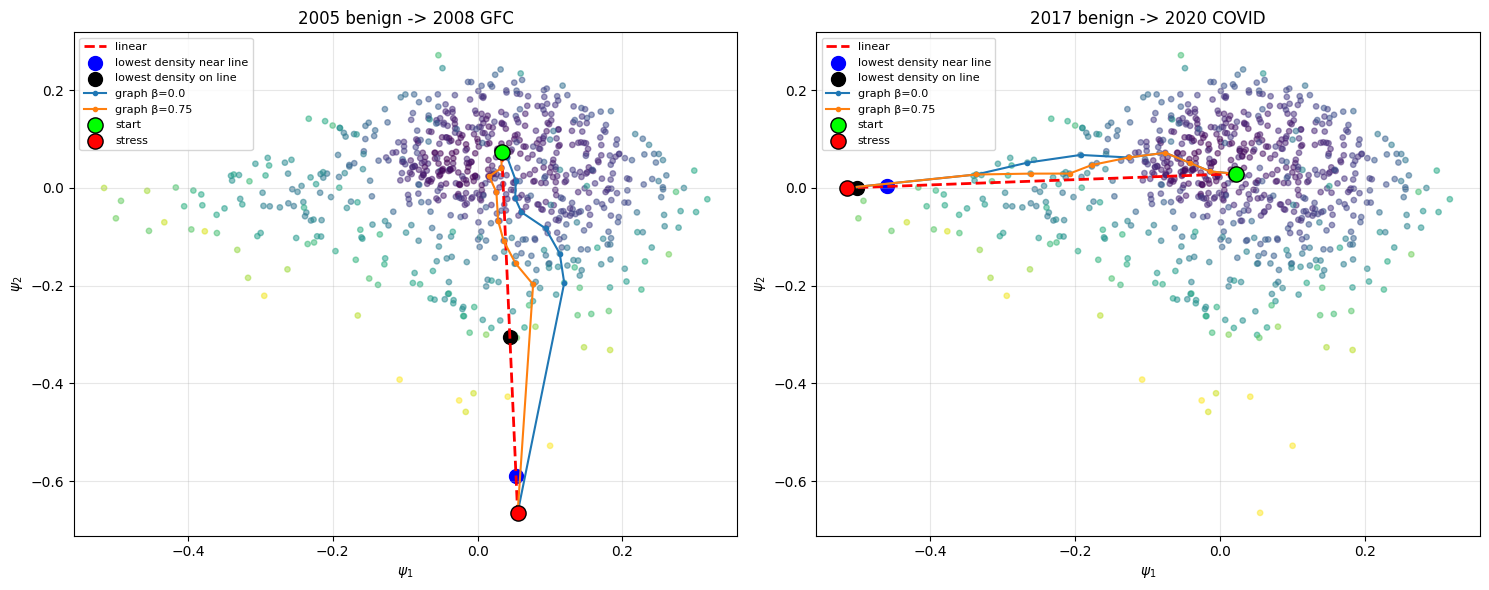

                endpoints         path  interior_min_rho  mean_rho  min_rho_lin  mean_rho_lin  max_NNdist
  2005 benign -> 2008 GFC       linear            0.0292    0.3569       0.0008        0.3163      0.1484
  2005 benign -> 2008 GFC  graph β=0.0            0.1706    1.1720       0.1706        1.1720      0.0000
  2005 benign -> 2008 GFC graph β=0.75            0.3120    1.2282       0.3120        1.2282      0.0000
2017 benign -> 2020 COVID       linear            0.0495    0.7355       0.0541        0.7001      0.0587
2017 benign -> 2020 COVID  graph β=0.0            0.1861    1.2254       0.1861        1.2254      0.0000
2017 benign -> 2020 COVID graph β=0.75            0.1861    1.1469       0.1861        1.1469      0.0000


In [7]:
# [C10] Primary metric: the endpoints are SHARED by all paths and a crisis endpoint is itself
# low-density, so min-over-the-whole-path is dominated by the shared endpoint and cannot
# discriminate. Report (a) min density over INTERIOR points, (b) mean density, (c) max NN distance
# to the cloud. The discriminating signals are mean-density and NN-distance.

median_Dsq = np.median(squareform(pdist(Psi)**2)[np.triu_indices(N,1)])
h = 0.1*median_Dsq; rho, V, scale = graph_degree_density(Psi, h=h)
# I had this function from Phase 4 to find the density of the line, I test it here
def latent_density_at_points(gamma, Psi, h, scale):
    Dsq_query = cdist(gamma, Psi, metric="sqeuclidean")
    rho_query = np.exp(-Dsq_query / h).sum(axis=1)
    rho_query = rho_query/scale
    rho_query_floor = np.maximum(rho_query, 1e-6)
    V_query = -np.log(rho_query_floor)
    return rho_query_floor, V_query

def interior_min_mean(idx_path):
    interior = idx_path[1:-1] if len(idx_path) > 2 else idx_path
    return rho[interior].min(), rho[interior].mean()

def lin_interior_min_mean(s, e, h, scale, n=40):
    lin = np.linspace(Psi[s], Psi[e], n)[1:-1]
    nn = np.array([np.argmin(np.linalg.norm(Psi - p, axis=1)) for p in lin])
    rho_lin, _ = latent_density_at_points(lin, Psi, h, scale)
    min_nn_idx, min_lin_idx = np.argmin(rho[nn]), np.argmin(rho_lin)
    return rho[nn].min(), rho[nn].mean(), rho_lin.min(), rho_lin.mean(), nn_dist_to_cloud(lin).max(), min_nn_idx, min_lin_idx


betas = [0.0, 0.75] #[0.0, 0.5, 1.0, 2.0]
summary = []
fig, axes = plt.subplots(1, len(pairs), figsize=(15, 6))
for ax, (name, (s, e)) in zip(np.atleast_1d(axes), pairs.items()):
    ax.scatter(Psi[:,0], Psi[:,1], c=V, s=15, cmap="viridis", alpha=.5)
    lin = np.linspace(Psi[s], Psi[e], 40)
    ax.plot(lin[:,0], lin[:,1], "r--", lw=2, label="linear")
    lmin, lmean, llmin, llmean, lnn, nn_idx, lin_idx = lin_interior_min_mean(s, e, h, scale)
    ax.scatter(*lin[nn_idx+1, :2], c="blue", s=100, label="lowest density near line")
    ax.scatter(*lin[lin_idx+1, :2], c="k", s=100, label="lowest density on line")
    summary.append((name, "linear", lmin, lmean, llmin, llmean, lnn))
    for beta in betas:
        p = graph_path(A_dist_sym, beta, V, s, e); P = Psi[p]
        ax.plot(P[:,0], P[:,1], marker="o", ms=3, label=f"graph β={beta}")
        imin, imean = interior_min_mean(p)
        summary.append((name, f"graph β={beta}", imin, imean, imin, imean, nn_dist_to_cloud(P).max()))
    ax.scatter(*Psi[s,:2], c="lime", s=120, ec="k", zorder=5, label="start")
    ax.scatter(*Psi[e,:2], c="red", s=120, ec="k", zorder=5, label="stress")
    ax.set_title(name); ax.set_xlabel(r"$\psi_1$"); ax.set_ylabel(r"$\psi_2$")
    ax.legend(fontsize=8); ax.grid(alpha=.3)
plt.tight_layout(); plt.show()

res = pd.DataFrame(summary, columns=["endpoints","path","interior_min_rho","mean_rho", "min_rho_lin", "mean_rho_lin", "max_NNdist"])
print(res.round(4).to_string(index=False))

### Reading the result

The dissertation claim is operationalised by two columns: **min_density** (higher is better, the path
stays in historically populated regions) and **max_NNdist_to_cloud** (lower is better, the path stays
near observed data). The linear path should show the lowest min-density and the largest
NN-distance (it cuts through the void); the graph paths, even at beta=0, cannot leave the data
because there are no edges across empty regions, and beta>0 pushes them further into dense regions.


The density function looked wrong in the above plot, the black point in the GFC plot looked to be in a high density region. Plotting all 3 dimensions below reveals that it is actually in a low density area and I now believe that the function is working properly.

In [10]:
betas = [0.0, 0.5, 1.0, 2.0]

num_pairs = len(pairs)
fig = make_subplots(rows=1, cols=num_pairs, subplot_titles=list(pairs.keys()),
                    specs=[[{'type': 'scene'} for _ in range(num_pairs)]])

for col_idx, (name, (s, e)) in enumerate(pairs.items(), start=1):
    fig.add_trace(go.Scatter3d(x=Psi[:, 0], y=Psi[:, 1], z=Psi[:, 2], mode='markers', 
                               marker=dict(size=3, color=-V, colorscale='Viridis', 
                                           opacity=0.9, showscale=False), name='Data Cloud',
                                             legendgroup=name, showlegend=(col_idx == 1)), row=1, col=col_idx)
    
    lin = np.linspace(Psi[s], Psi[e], 40)
    lmin, lmean, llmin, llmean, lnn, nn_idx, lin_idx = lin_interior_min_mean(s, e, h, scale)
    
    fig.add_trace(go.Scatter3d(x=lin[:, 0], y=lin[:, 1], z=lin[:, 2],
                               mode='lines', line=dict(color='red', width=4, dash='dash'),
                               name='Linear Path', legendgroup=name, showlegend=(col_idx == 1)),
                               row=1, col=col_idx)
    
    fig.add_trace(go.Scatter3d(x=[lin[nn_idx+1, 0]], y=[lin[nn_idx+1, 1]], z=[lin[nn_idx+1, 2]],
                                mode='markers', marker=dict(size=8, color='blue'), name='Lowest density near line',
                                legendgroup=name, showlegend=(col_idx == 1)), row=1, col=col_idx)
    
    fig.add_trace(go.Scatter3d(x=[lin[lin_idx+1, 0]], y=[lin[lin_idx+1, 1]], z=[lin[lin_idx+1, 2]], mode='markers', 
                               marker=dict(size=8, color='black'), name='Lowest density on line', legendgroup=name, 
                               showlegend=(col_idx == 1)), row=1, col=col_idx)
    
    for beta in betas:
        p = graph_path(A_dist_sym, beta, V, s, e); P = Psi[p]
        
        fig.add_trace(go.Scatter3d(x=P[:, 0], y=P[:, 1], z=P[:, 2], mode='lines+markers', marker=dict(size=4),
                                   name=f"graph β={beta}", legendgroup=name, showlegend=(col_idx == 1)), row=1, col=col_idx)
        
    fig.add_trace(go.Scatter3d(x=[Psi[s, 0]], y=[Psi[s, 1]], z=[Psi[s, 2]], mode='markers', 
                               marker=dict(size=10, color='lime', line=dict(color='black', width=2)),
                               name='Start', legendgroup=name, showlegend=(col_idx == 1)), row=1, col=col_idx)
    
    fig.add_trace(
        go.Scatter3d(x=[Psi[e, 0]], y=[Psi[e, 1]], z=[Psi[e, 2]], mode='markers',
                     marker=dict(size=10, color='red', line=dict(color='black', width=2)),
                     name='Stress', legendgroup=name, showlegend=(col_idx == 1)), row=1, col=col_idx)

    fig.update_scenes(xaxis_title=r'psi_1', yaxis_title='psi_2', zaxis_title=r'psi_3', row=1, col=col_idx)

fig.update_layout(height=600, width=500 * num_pairs, margin=dict(l=20, r=20, t=40, b=20), 
                  legend=dict(orientation="h", yanchor="bottom", y=1.02, xanchor="right", x=1))

fig.show()

# Using my own points + further analysis

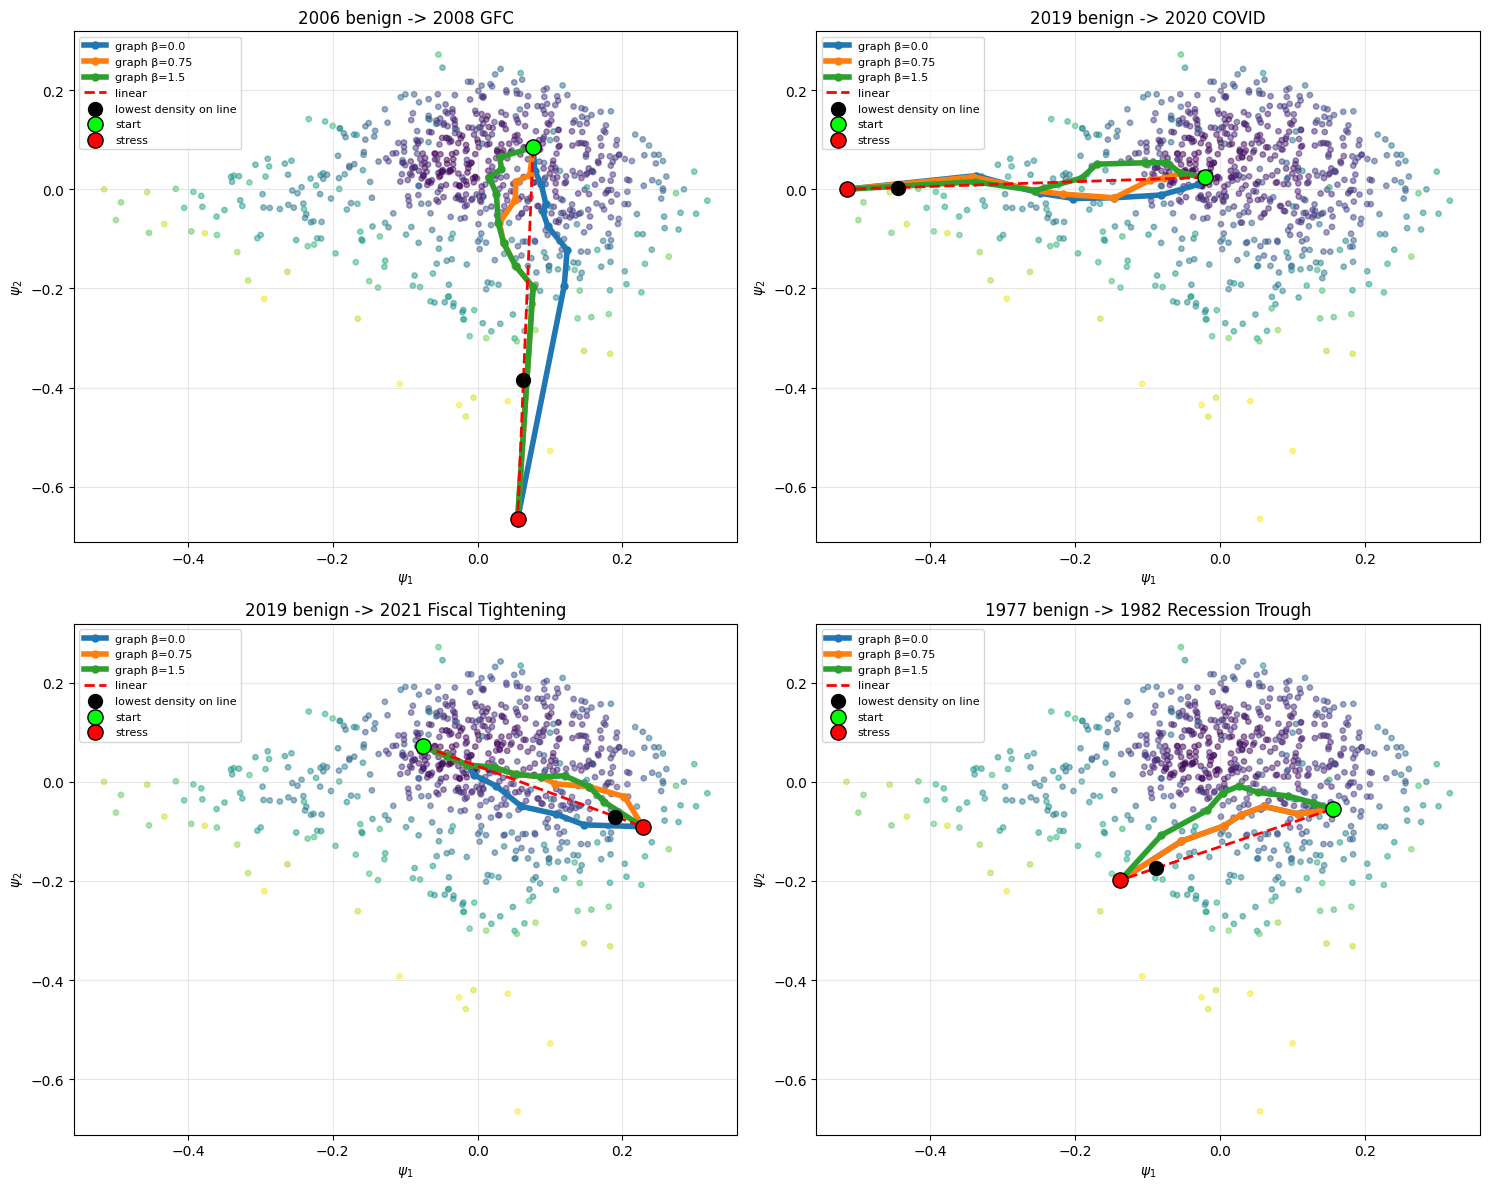

                            endpoints         path  interior_min_rho  mean_rho  min_rho_lin  mean_rho_lin  max_NNdist
              2006 benign -> 2008 GFC  graph β=0.0            0.1706    1.1336       0.1706        1.1336      0.0000
              2006 benign -> 2008 GFC graph β=0.75            0.3120    1.1213       0.3120        1.1213      0.0000
              2006 benign -> 2008 GFC  graph β=1.5            0.3120    1.3036       0.3120        1.3036      0.0000
              2006 benign -> 2008 GFC       linear            0.0292    0.3084       0.0028        0.3045      0.1127
            2019 benign -> 2020 COVID  graph β=0.0            0.1861    0.6669       0.1861        0.6669      0.0000
            2019 benign -> 2020 COVID graph β=0.75            0.2406    0.9343       0.2406        0.9343      0.0000
            2019 benign -> 2020 COVID  graph β=1.5            0.2591    0.9639       0.2591        0.9639      0.0000
            2019 benign -> 2020 COVID       linear      

In [ ]:
endpoint_pairs = {"2006 benign -> 2008 GFC": ("2006-03-01", "2008-10-01"), "2019 benign -> 2020 COVID": ("2019-07-01", "2020-04-01"), 
                  "2019 benign -> 2021 Fiscal Tightening": ("2019-04-01", "2022-04-01"), "1977 benign -> 1982 Recession Trough": ("1977-01-01", "1982-07-01")}
pairs = {name: (dates.get_loc(pair[0]), dates.get_loc(pair[1])) for name, pair in endpoint_pairs.items()}

betas = [0.0, 0.75, 1.5]
summary = []
fig, axes = plt.subplots(2, 2, figsize=(15, 12))

for ax, (name, (s, e)) in zip(axes.flatten(), pairs.items()):
    
    ax.scatter(Psi[:,0], Psi[:,1], c=V, s=15, cmap="viridis", alpha=.5)
    
    path_lengths = []
    for beta in betas:
        p = graph_path(A_dist_sym, beta, V, s, e)
        P = Psi[p]; path_lengths.append(len(P))
        ax.plot(P[:,0], P[:,1], marker="o", ms=5, label=f"graph β={beta}", linewidth=4)
        imin, imean = interior_min_mean(p)
        summary.append((name, f"graph β={beta}", imin, imean, imin, imean, nn_dist_to_cloud(P).max()))

    # Changed the number of points in linear path to average of points in graph paths
    n_grid = int(np.mean(path_lengths))
    lin = np.linspace(Psi[s], Psi[e], n_grid)
    ax.plot(lin[:,0], lin[:,1], "r--", lw=2, label="linear")
    
    lmin, lmean, llmin, llmean, lnn, nn_idx, lin_idx = lin_interior_min_mean(s, e, h_dens, scale, n=n_grid)

    ax.scatter(*lin[lin_idx+1, :2], c="k", s=100, zorder=5, label="lowest density on line")
    summary.append((name, "linear", lmin, lmean, llmin, llmean, lnn))
    

    ax.scatter(*Psi[s,:2], c="lime", s=120, ec="k", zorder=5, label="start")
    ax.scatter(*Psi[e,:2], c="red", s=120, ec="k", zorder=5, label="stress")

    ax.set_title(name)
    ax.set_xlabel(r"$\psi_1$")
    ax.set_ylabel(r"$\psi_2$")
    ax.legend(fontsize=8)
    ax.grid(alpha=.3)

plt.tight_layout()
plt.show()

res = pd.DataFrame(summary, columns=["endpoints","path","interior_min_rho","mean_rho", "min_rho_lin", "mean_rho_lin", "max_NNdist"])
print(res.round(4).to_string(index=False))

For fairness, I changed the number of points in the linear line to be the average number of points in the graph paths. This is because when the linear line had 40 points, the minimum interior density was always very close to the stress scenario, meaning it always had a very low density.

<span style="color:red">If we use the `interior_mean_rho` metric, we find the following results.</span> We get the exact same min level of density because the way this metric is calculated is by finding the closest node to each point on the line and returning the lowest level of density amoung those nodes. This happens to be the same value for the linear line and the path for $\beta=1.5$. The minimum density is higher for the linear path than the minimum density of the graph paths for $\beta \in \{0.0, 0.75\}$. **I don't think I will use this metric so I don't know if I will actually find the following results, but here is my attempt at an explanation anyway.**

#### Subset of results above for easy reading: `2019 benign -> 2021 Fiscal Tightening`
| Path | Interior Minimum Density | Interior Mean Density |
| :--- | :--- | :--- |
| $\beta = 0.0$ | 0.8514 | 1.6905 |
| $\beta = 0.75$ | 0.9182 | 1.7466 |
| $\beta = 1.5$ | 0.9474 | 1.7534 |
| Linear | 0.9474 | 1.7091 |


This change results in the minimum density of the linear path to be *higher* than that of the density aware path for $\beta\in \{0.0, 0.75\}$ in the `2019 benign -> 2021 Fiscal Tightening` scenario. **This breaks our hypothesis...** However, this path raised some issues in Phase 6 where we saw that the cost per unit length for the linear path was lower than that of the standard graph path. This was explained by noting that the stress situation lies just on the edge of the highly-dense region and the benign scenario is in the middle of the highly-dense region, therefore a linear path from benign to stressed is actually a realistic path because it always remains in a high density region.

For the graph paths, minimising the cost ($\|\psi_i - \psi_j\|\exp(\beta\frac{V_i+V_j}{2})$) in a high-density region is very similar to minimsing the distances, since the density-aware costs for each node are small in comparison to the distance cost, i.e. the exponential term in the cost isn't as important as the distance term in highly dense regions. 

The linear path is a realistic path because it goes directly through a very dense region; if there were observed nodes along that path, the graph paths would have followed them. This highlights an important point that the density-aware paths may not be useful or necessary if we are traversing through highly dense regions of our latent space. The density-aware method works far better when we are in very stressed scenarios like COVID or 2008 GFC.

If we want to get rid of this anomoly, could we choose our $\beta$ value to make the density penalty be of the same order as the distance penalty in higly-dense regions? I.e.
$$

\mathcal{O}(\min_{i,j} \left[\exp(\beta\frac{V_i + V_j}{2})\right]) = \mathcal{O}(\|\psi_p - \psi_q\|) \ \text{for } p, q \in \{k \ |\ \rho_k > \text{threshold}\}

$$

<span style="color:red">End of discussion of `interior_min_rho` results.</span>

#### Changing density calculation
Since we are using the local-neighbourhood lifting (LNL) technique, instead of finding the density of points along the straight line in latent space, we can find the density of the points along the path taken by the LNL function. The LNL method maps each point along the line in latent space to the macro space by the following linear combination: 
$$\hat z(s) = \sum_{j\in\mathcal{N}_m(\gamma(s))}a_j(s)\tilde z_j,$$ where $$a_j(s) = \frac{\exp(-\|\gamma(s) - \psi_j\|^2/\tau)}{\sum_{k\in\mathcal{N}_m(\gamma(s))}\exp(-\|\gamma(s) - \psi_k\|^2/\tau)},$$
and $\mathcal{N}_m(\gamma(s))$ is the $m$ nearest training points to $\gamma(s)$ in the latent space.

This means that we are essentially warping our straight line in latent space by moving it closer to its neighbours - this is what makes the LNL method better (in terms of more realistic paths) than the linear operator $H$ used in Baker et. al. It would make sense then to calculate the density of this warped path in latent space rather than the straight one. To do this, I simply take a linear combination of the latent coordinates at each point of $\gamma(s)$, weighting it by $a_j(s)$, giving the new path in latent space as:
$$
\gamma^\text{LNL}(s) = \sum_{j\in\mathcal{N}_m(\gamma(s))}a_j(s)\psi_j
$$

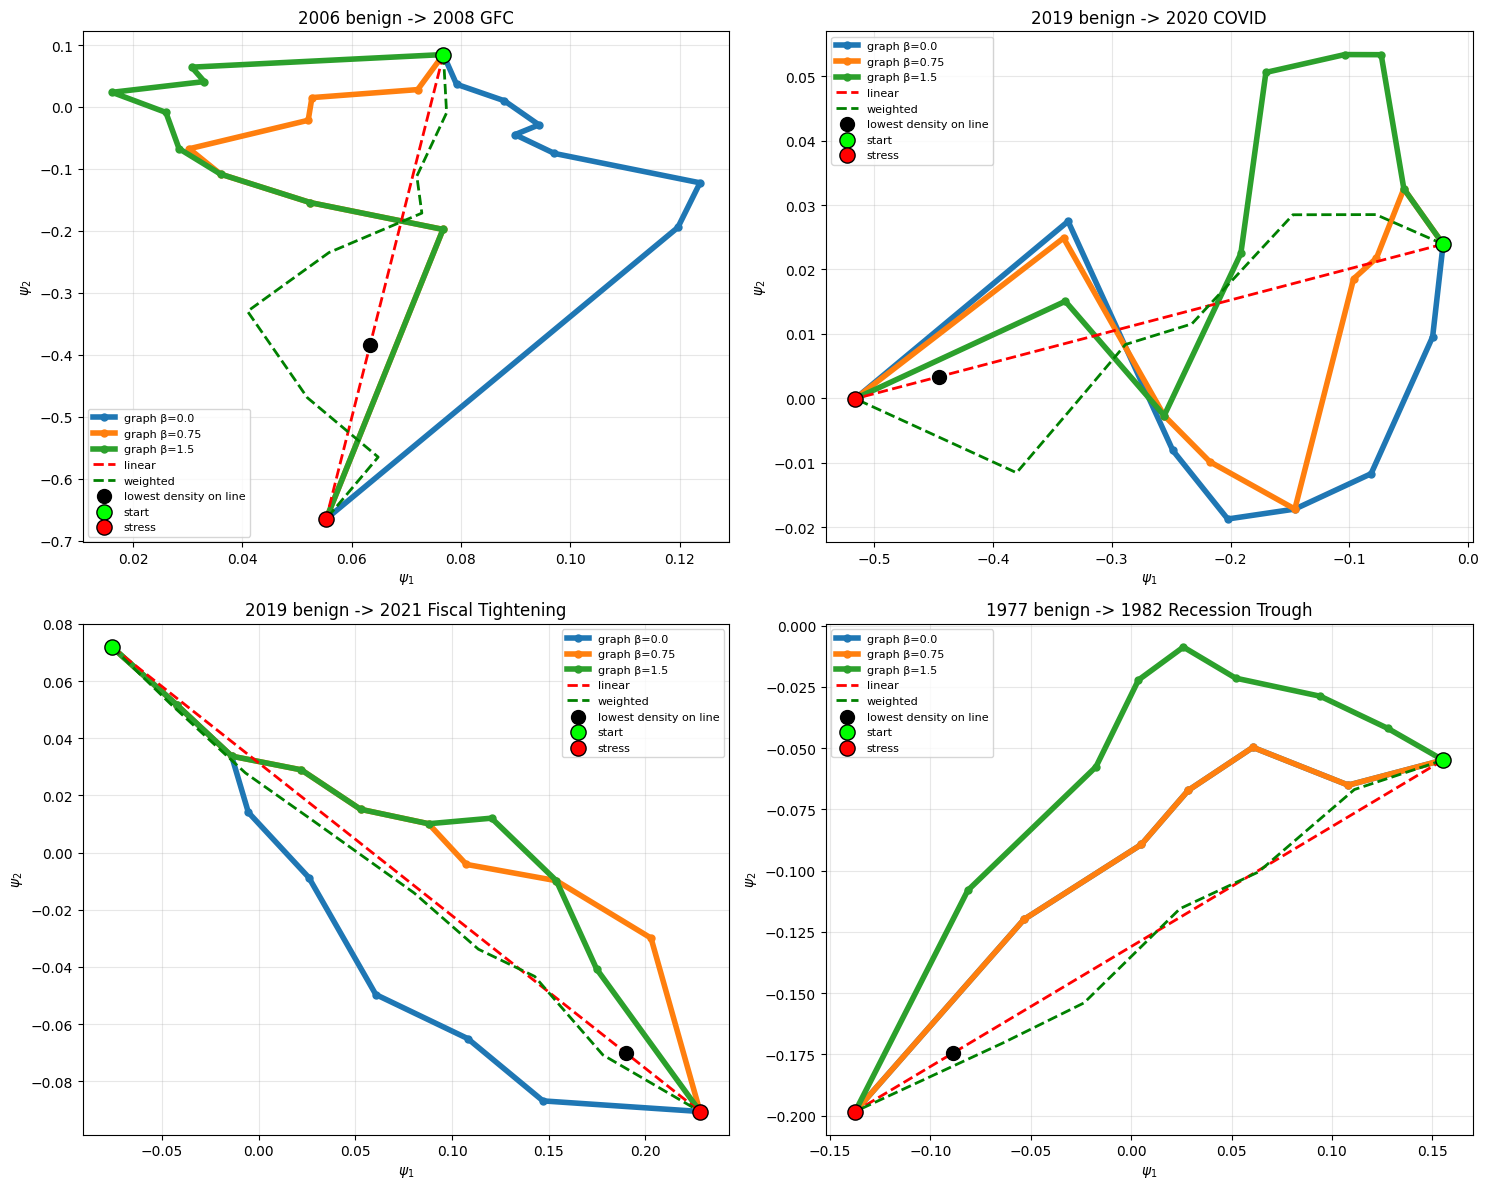

                            endpoints         path  interior_min_rho  mean_rho  min_rho_lin  mean_rho_lin  min_rho_weighted  mean_rho_weighted  max_NNdist
              2006 benign -> 2008 GFC  graph β=0.0            0.1706    1.1336       0.1706        1.1336            0.1706             1.1336      0.0000
              2006 benign -> 2008 GFC graph β=0.75            0.3120    1.1213       0.3120        1.1213            0.3120             1.1213      0.0000
              2006 benign -> 2008 GFC  graph β=1.5            0.3120    1.3036       0.3120        1.3036            0.3120             1.3036      0.0000
              2006 benign -> 2008 GFC       linear            0.0292    0.3084       0.0028        0.3045            0.0070             0.4265      0.1127
            2019 benign -> 2020 COVID  graph β=0.0            0.1861    0.6669       0.1861        0.6669            0.1861             0.6669      0.0000
            2019 benign -> 2020 COVID graph β=0.75            0.2406  

In [56]:
def weighted_latent_line(gamma, start_idx, end_idx, tau, m):
    nn = NearestNeighbors(n_neighbors=m); nn.fit(Psi)
    distances, indices = nn.kneighbors(gamma)
    a = np.exp(-distances**2/tau) / np.sum(np.exp(-distances**2 / tau), axis=1, keepdims=True)
    points = Psi[indices, :]; gamma_lnl = np.sum(a[:, :, None] * points, axis=1)
    gamma_lnl[0], gamma_lnl[-1] = Psi[start_idx], Psi[end_idx]
    return gamma_lnl

betas = [0.0, 0.75, 1.5]; summary = []
fig, axes = plt.subplots(2, 2, figsize=(15, 12))

for ax, (name, (s, e)) in zip(axes.flatten(), pairs.items()):
    #ax.scatter(Psi[:,0], Psi[:,1], c=V, s=15, cmap="viridis", alpha=.5)
    path_lengths = []
    for beta in betas:
        p = graph_path(A_dist_sym, beta, V, s, e); P = Psi[p]; path_lengths.append(len(P))
        ax.plot(P[:,0], P[:,1], marker="o", ms=5, label=f"graph β={beta}", linewidth=4)
        imin, imean = interior_min_mean(p)
        summary.append((name, f"graph β={beta}", imin, imean, imin, imean, imin, imean, nn_dist_to_cloud(P).max()))

    n_grid = int(np.mean(path_lengths)); lin = np.linspace(Psi[s], Psi[e], n_grid)
    ax.plot(lin[:,0], lin[:,1], "r--", lw=2, label="linear")

    lin_weighted = weighted_latent_line(lin, s, e, med_Dsq, m=22)
    ax.plot(lin_weighted[:,0], lin_weighted[:,1], "g--", lw=2, label="weighted")

    lmin, lmean, llmin, llmean, lnn, nn_idx, lin_idx = lin_interior_min_mean(s, e, h_dens, scale, n=n_grid)

    rho_weighted, _ = latent_density_at_points(lin_weighted, Psi, h_dens, scale)
    lwmin = rho_weighted.min(); lwmean = rho_weighted.mean()

    ax.scatter(*lin[lin_idx+1, :2], c="k", s=100, zorder=5, label="lowest density on line")
    summary.append((name, "linear", lmin, lmean, llmin, llmean, lwmin, lwmean, lnn))

    ax.scatter(*Psi[s,:2], c="lime", s=120, ec="k", zorder=5, label="start")
    ax.scatter(*Psi[e,:2], c="red", s=120, ec="k", zorder=5, label="stress")

    ax.set_title(name); ax.set_xlabel(r"$\psi_1$")
    ax.set_ylabel(r"$\psi_2$"); ax.legend(fontsize=8)
    ax.grid(alpha=.3) 

plt.tight_layout()
plt.show()

res = pd.DataFrame(summary, columns=["endpoints","path","interior_min_rho","mean_rho", "min_rho_lin", "mean_rho_lin", "min_rho_weighted", "mean_rho_weighted", "max_NNdist"])
print(res.round(4).to_string(index=False))


These results don't change things dramatically compared to the standard linear density function. The weighted path on average seems to have a higher density, but the minimum density along the path is actually smaller than the minimum density along the straight path. Each point is moved towards the weighted average of its neighbours, this can drag the point into an even lower density region, however on average this doesn't seem to happen. 

I also didn't expect to see the lines to look the way they do; I expected them to look closer to the garph paths. I think this metric seems a bit useless and I will not be using it going farward.